# Задание 2: Бифуркационный анализ модели химической кинетики
**Исследуемая система: Модель № 4**

Математическая модель (уравнения ОДУ) на поверхности катализатора:
$$\frac{dx}{dt} = k_1 z - k_{-1} x - k_3 x + k_{-3} y - k_2 z^2 x$$
$$\frac{dy}{dt} = k_3 x - k_{-3} y$$
Где $z = 1 - x - y$ (концентрация свободных мест).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp


plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

k2_base = 2.0
k3 = 0.0032
k3m_base = 0.002  # k_{-3}
k1m_base = 0.01   # k_{-1}

## 1. Однопараметрический анализ (Задание 1.1 - 1.3)
**Этапы 1-4 со страниц 5-12:**
1. Аналитическое продолжение по параметру (解析延拓).
2. Расчет элементов матрицы Якоби (计算雅可比矩阵).
3. Вычисление следа и определителя (计算迹和行列式).
4. Поиск точек бифуркаций (寻找分岔点).

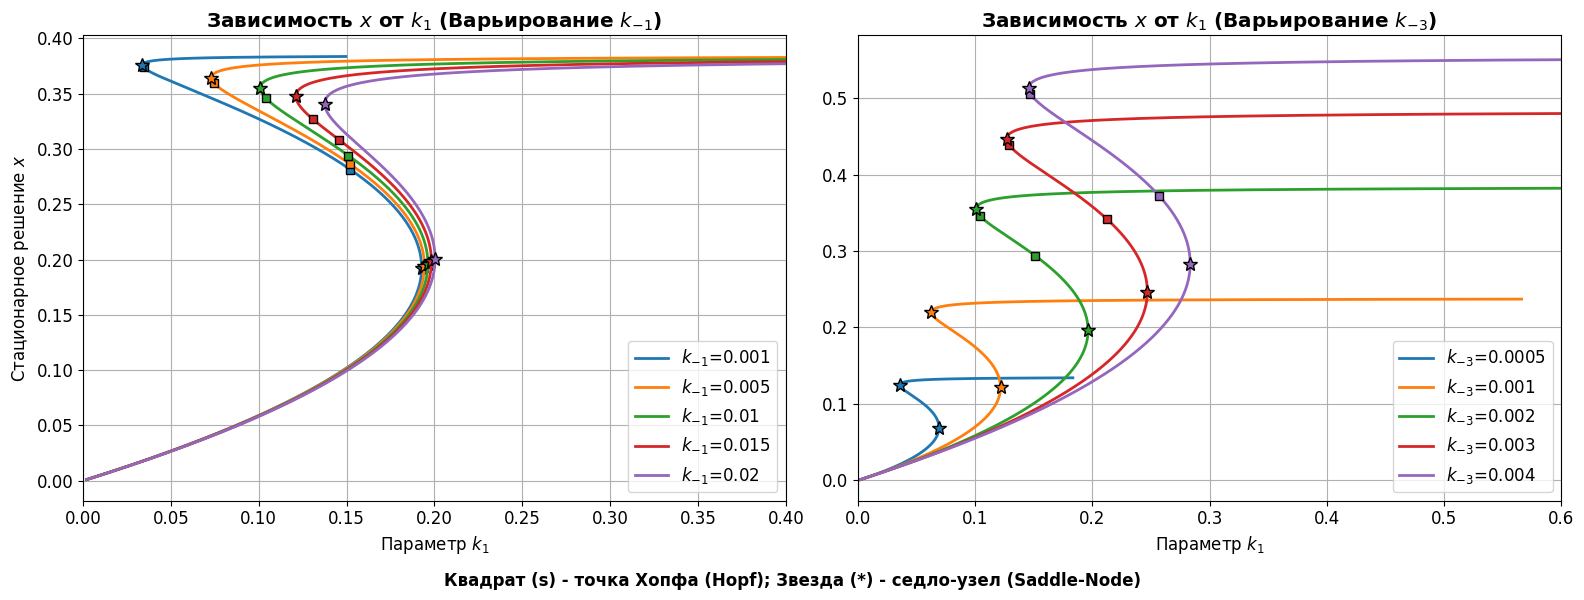

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Задание 1.1: Варьирование k_{-1} ---
k1m_list = [0.001, 0.005, 0.01, 0.015, 0.02]
for k1m in k1m_list:
    R = k3 / k3m_base
    M = 1 + R
    x = np.linspace(0.001, 1/M - 0.001, 2000)
    y = R * x
    z = 1 - x - y
    
    # Этап 1: Аналитическое вычисление k1
    k1 = (x / z) * (k1m + k2_base * z**2)
    
    # Этап 2 & 3: Матрица Якоби, След (Tr) и Определитель (Det)
    a11 = -k1 - k1m - k3 - k2_base*z**2 + 2*k2_base*z*x
    a12 = -k1 + k3m_base + 2*k2_base*z*x
    a21, a22 = k3, -k3m_base
    
    Tr, Det = a11 + a22, a11*a22 - a12*a21
    valid = k1 > 0
    
    p = axes[0].plot(k1[valid], x[valid], label=f'$k_{{-1}}$={k1m}')
    color = p[0].get_color()
    
    # Этап 4: Бифуркации
    idx_hopf = np.where(np.diff(np.sign(Tr[valid])))[0]
    idx_sn = np.where(np.diff(np.sign(Det[valid])))[0]
    
    if len(idx_hopf) > 0:
        axes[0].plot(k1[valid][idx_hopf], x[valid][idx_hopf], 's', color=color, markersize=6, markeredgecolor='k')
    if len(idx_sn) > 0:
        axes[0].plot(k1[valid][idx_sn], x[valid][idx_sn], '*', color=color, markersize=10, markeredgecolor='k')

axes[0].set_title('Зависимость $x$ от $k_1$ (Варьирование $k_{-1}$)', fontweight='bold')
axes[0].set_xlabel('Параметр $k_1$')
axes[0].set_ylabel('Стационарное решение $x$')
axes[0].set_xlim(0, 0.4)
axes[0].legend()

# --- Задание 1.2: Варьирование k_{-3} ---
k3m_list = [0.0005, 0.001, 0.002, 0.003, 0.004]
for k3m_val in k3m_list:
    R = k3 / k3m_val
    M = 1 + R
    x = np.linspace(0.001, 1/M - 0.001, 2000)
    y = R * x
    z = 1 - x - y
    k1 = (x / z) * (k1m_base + k2_base * z**2)
    
    a11 = -k1 - k1m_base - k3 - k2_base*z**2 + 2*k2_base*z*x
    a12 = -k1 + k3m_val + 2*k2_base*z*x
    a21, a22 = k3, -k3m_val
    
    Tr, Det = a11 + a22, a11*a22 - a12*a21
    valid = k1 > 0
    
    p = axes[1].plot(k1[valid], x[valid], label=f'$k_{{-3}}$={k3m_val}')
    color = p[0].get_color()
    
    idx_hopf = np.where(np.diff(np.sign(Tr[valid])))[0]
    idx_sn = np.where(np.diff(np.sign(Det[valid])))[0]
    
    if len(idx_hopf) > 0:
        axes[1].plot(k1[valid][idx_hopf], x[valid][idx_hopf], 's', color=color, markersize=6, markeredgecolor='k')
    if len(idx_sn) > 0:
        axes[1].plot(k1[valid][idx_sn], x[valid][idx_sn], '*', color=color, markersize=10, markeredgecolor='k')

axes[1].set_title('Зависимость $x$ от $k_1$ (Варьирование $k_{-3}$)', fontweight='bold')
axes[1].set_xlabel('Параметр $k_1$')
axes[1].set_xlim(0, 0.6)
axes[1].legend()

# Фиктивные графики для общей легенды маркеров
fig.text(0.5, 0.01, 'Квадрат (s) - точка Хопфа (Hopf); Звезда (*) - седло-узел (Saddle-Node)', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 2. Двухпараметрический анализ (Задание 2.1)
Построение параметрического портрета на плоскости $(k_1, k_2)$.
Линии кратности (Saddle-node) и нейтральности (Hopf). Точки ко-размерности-2: Cusp (C) и Takens-Bogdanov (TB).

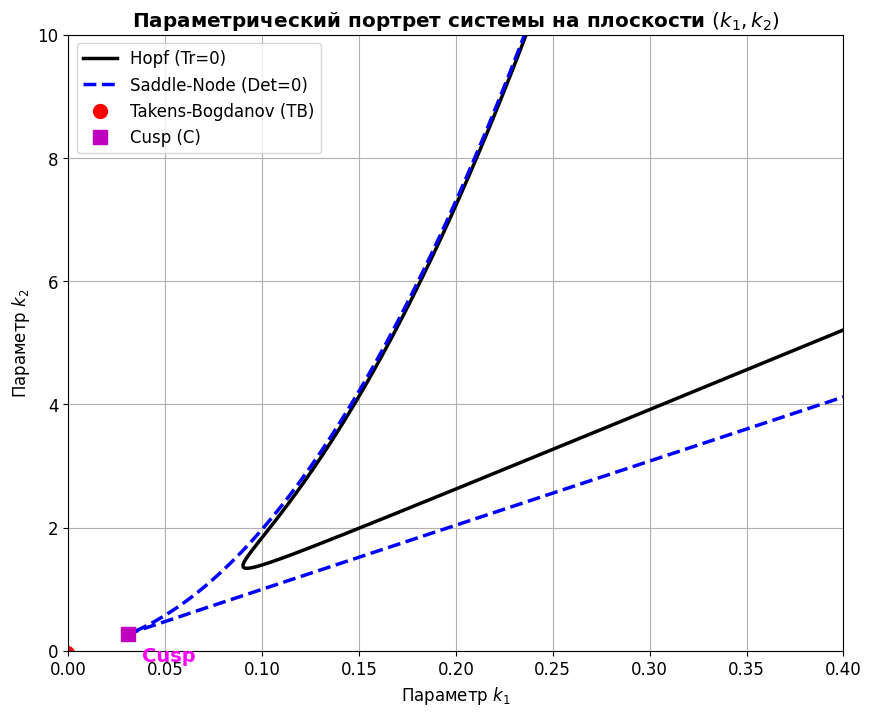

In [3]:
k1m = 0.01
k3m = 0.002
R = k3 / k3m
M = 1 + R

x = np.linspace(0.001, 1/M - 0.001, 5000)
y = R * x
z = 1 - x - y

# Линия нейтральности (Hopf, Tr=0)
k2_hopf = (k1m*(x+z)/z + k3 + k3m) / (z*(x-z))
k1_hopf = (x/z) * (k1m + k2_hopf * z**2)
valid_hopf = (k2_hopf > 0) & (k1_hopf > 0)

# Линия кратности (Saddle-Node, Det=0)
k2_sn = k1m * (x*(k3+k3m) + z*k3m) / (z**2 * (x*(k3+k3m) - z*k3m))
k1_sn = (x/z) * (k1m + k2_sn * z**2)
valid_sn = (k2_sn > 0) & (k1_sn > 0)

# Поиск точки Takens-Bogdanov (TB)
def tb_equation(x_val):
    z_val = 1 - M*x_val
    k2_h = (k1m*(x_val+z_val)/z_val + k3 + k3m) / (z_val*(x_val-z_val))
    k2_s = k1m * (x_val*(k3+k3m) + z_val*k3m) / (z_val**2 * (x_val*(k3+k3m) - z_val*k3m))
    return k2_h - k2_s

x_tb = fsolve(tb_equation, 0.15)[0] 
z_tb = 1 - M*x_tb
k2_tb = (k1m*(x_tb+z_tb)/z_tb + k3 + k3m) / (z_tb*(x_tb-z_tb))
k1_tb = (x_tb/z_tb) * (k1m + k2_tb * z_tb**2)

# Поиск точки Cusp (C)
idx_cusp = np.argmin(k1_sn[valid_sn])
k1_c = k1_sn[valid_sn][idx_cusp]
k2_c = k2_sn[valid_sn][idx_cusp]

plt.figure(figsize=(10, 8))
plt.plot(k1_hopf[valid_hopf], k2_hopf[valid_hopf], 'k-', linewidth=2.5, label='Hopf (Tr=0)')
plt.plot(k1_sn[valid_sn], k2_sn[valid_sn], 'b--', linewidth=2.5, label='Saddle-Node (Det=0)')

plt.plot(k1_tb, k2_tb, 'ro', markersize=10, label='Takens-Bogdanov (TB)')
plt.annotate('TB', (k1_tb, k2_tb), xytext=(10, 10), textcoords='offset points', fontsize=14, color='red', fontweight='bold')

plt.plot(k1_c, k2_c, 'ms', markersize=10, label='Cusp (C)')
plt.annotate('Cusp', (k1_c, k2_c), xytext=(10, -20), textcoords='offset points', fontsize=14, color='magenta', fontweight='bold')

plt.title('Параметрический портрет системы на плоскости $(k_1, k_2)$', fontweight='bold')
plt.xlabel('Параметр $k_1$')
plt.ylabel('Параметр $k_2$')
plt.xlim(0, 0.4)
plt.ylim(0, 10)
plt.legend(loc='upper left')
plt.show()

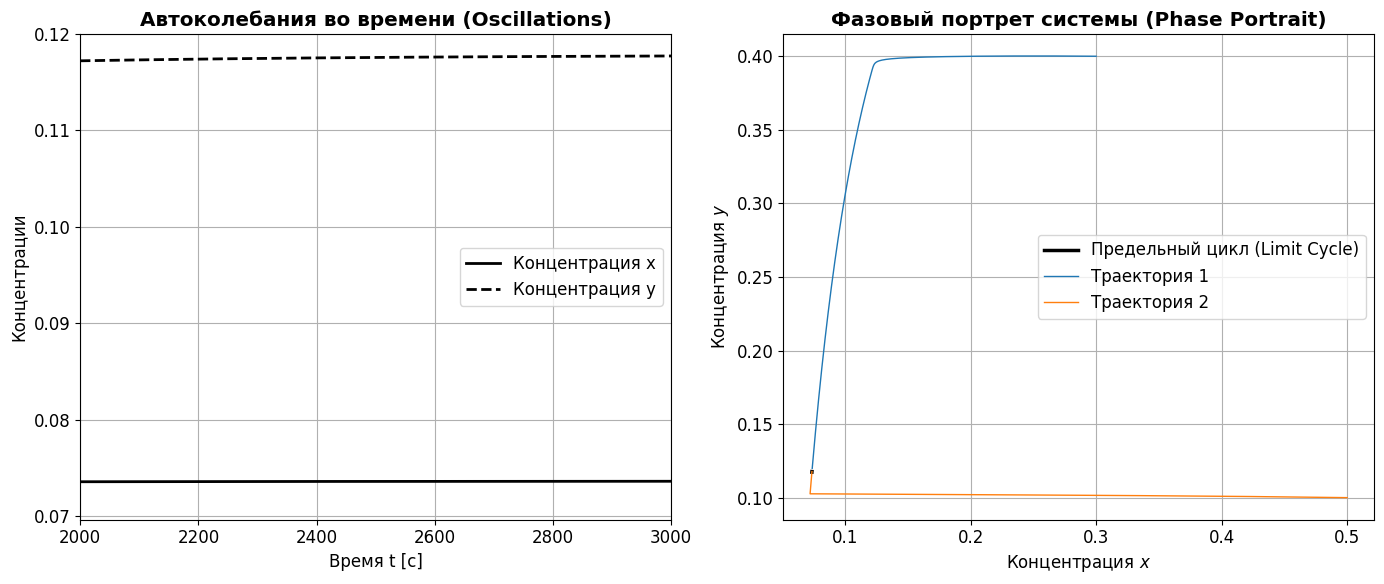

In [4]:
# Выбор параметров из области автоколебаний (между линиями Hopf)
k1_sim = 0.12
k2_sim = 2.0

# Функция правой части ОДУ для Модели №4
def model4_ode(t, Y):
    x, y = Y
    z = 1 - x - y
    dxdt = k1_sim * z - k1m_base * x - k3 * x + k3m_base * y - k2_sim * (z**2) * x
    dydt = k3 * x - k3m_base * y
    return [dxdt, dydt]

# Настройки решателя (аналог ode15s в MATLAB)
t_span = (0, 3000)
t_eval = np.linspace(0, 3000, 10000)
y0_list = [[0.1, 0.1], [0.3, 0.4], [0.5, 0.1]] # Разные начальные условия

plt.figure(figsize=(14, 6))

# --- График 1: Колебания во времени ---
plt.subplot(1, 2, 1)
sol_main = solve_ivp(model4_ode, t_span, y0_list[0], method='BDF', t_eval=t_eval, rtol=1e-7, atol=1e-8)
plt.plot(sol_main.t, sol_main.y[0], 'k-', label='Концентрация x')
plt.plot(sol_main.t, sol_main.y[1], 'k--', label='Концентрация y')
plt.title('Автоколебания во времени (Oscillations)', fontweight='bold')
plt.xlabel('Время t [с]')
plt.ylabel('Концентрации')
plt.xlim(2000, 3000) # Показываем только установившийся режим
plt.legend()

# --- График 2: Фазовый портрет ---
plt.subplot(1, 2, 2)
# Извлекаем установившийся предельный цикл (последние 30% времени)
idx_stable = int(len(sol_main.t) * 0.7)
plt.plot(sol_main.y[0][idx_stable:], sol_main.y[1][idx_stable:], 'k-', linewidth=2.5, label='Предельный цикл (Limit Cycle)')

# Рисуем траектории сходимости для других начальных условий
for i, y0 in enumerate(y0_list[1:]):
    sol = solve_ivp(model4_ode, t_span, y0, method='BDF', t_eval=t_eval, rtol=1e-7, atol=1e-8)
    plt.plot(sol.y[0], sol.y[1], linewidth=1, label=f'Траектория {i+1}')

plt.title('Фазовый портрет системы (Phase Portrait)', fontweight='bold')
plt.xlabel('Концентрация $x$')
plt.ylabel('Концентрация $y$')
plt.legend()
plt.tight_layout()
plt.show()